# Métricas de Clasificación Multiclase: NHANES Alcohol Use
Este cuadernillo tiene como objetivo adaptar el análisis de métricas de clasificación al entorno multiclase, utilizando el dataset *August 2021-August 2023 Questionnaire Data - Continuous NHANES*, específicamente la sección de uso de alcohol (Alcohol Use).

## Descripción del Dataset
El dataset de NHANES (National Health and Nutrition Examination Survey) recoge encuestas de salud de EE.UU. En este caso nos centramos en las respuestas sobre el consumo de bebidas alcohólicas (ALQ).
Las principales variables que utilizaremos para definir nuestras clases (Etiqueta o Target) son:
- **ALQ111**: ¿El paciente ha tomado al menos una bebida alcohólica en el pasado? (1=Sí, 2=No).
- **ALQ121**: ¿Con qué frecuencia bebió alcohol en los últimos 12 meses? (Respuestas que van desde todos los días hasta nunca).

Otras variables de hábitos (como qué tanto tomaron cuando lo hicieron) nos servirán como **características o features (X)** para intentar predecir a qué grupo pertenece la persona.

Hemos definido 3 clases (*Categoria_Bebedor*):
- **Clase 0 (No Bebedor / Bebedor Raro)**: Nunca toma o indica en ALQ111 que no ha tomado alcohol.
- **Clase 1 (Bebedor Moderado/Infrecuente)**: Personas con frecuencias de consumo espaciadas.
- **Clase 2 (Bebedor Frecuente)**: Aquellos que beben regularmente todos los días o de forma semanal.

A continuación vamos a cargar los datos y prepararlos.

In [1]:
import pandas as pd
import numpy as np

# 1. Cargar el dataset de NHANES (Asumimos que el archivo ALQ_L.xpt está en la misma carpeta)
df = pd.read_sas('ALQ_L.xpt')

# 2. Limpieza de datos
# Rellenamos nulos con 0 y reemplazamos el flag interno de SAS por 0 real
df = df.fillna(0)
df = df.replace(5.397605346934028e-79, 0)

# 3. Creación de la Variable Objetivo Multiclase
# Nos basamos en ALQ111 (¿Ha tomado alcohol?) y ALQ121 (Frecuencia en últimos 12 meses)
conditions = [
    (df['ALQ111'] == 2.0) | (df['ALQ121'] == 0) | (df['ALQ121'] == 10),  # Clase 0
    (df['ALQ121'] >= 5) & (df['ALQ121'] <= 9),                           # Clase 1
    (df['ALQ121'] >= 1) & (df['ALQ121'] <= 4)                            # Clase 2
]
choices = [0, 1, 2]
df['Categoria_Bebedor'] = np.select(conditions, choices, default=0)

# 4. Seleccionamos las columnas de características (preguntas de hábitos)
X = df[['ALQ130', 'ALQ142', 'ALQ270', 'ALQ280', 'ALQ151', 'ALQ170']].values
y = df['Categoria_Bebedor'].values

print("Distribución de las 3 Clases:")
print(df['Categoria_Bebedor'].value_counts())

Distribución de las 3 Clases:
Categoria_Bebedor
0    2798
1    2134
2    1405
Name: count, dtype: int64


## Separar los datos y Entrenar un Clasificador
A continuación separaremos los datos en entrenamiento y prueba, e instaciaremos un modelo de regresión logística preparado para multiclase (`multi_class='multinomial'`).

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# Separamos 80% para entrenar y 20% para evaluar
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Instanciamos y entrenamos el modelo multiclase
clf = LogisticRegression(max_iter=1000)
clf.fit(X_train, y_train)

# Generamos las predicciones discretas y las probabilidades
y_pred = clf.predict(X_test)
y_pred_proba = clf.predict_proba(X_test)

## 1. Métrica: Accuracy (Precisión Global)
**¿Para qué sirve y por qué la usamos?**
La Exactitud o *Accuracy* nos indica el porcentaje total de predicciones que nuestro modelo acertó (número de aciertos / total de predicciones). Es muy útil como una medida de pantallazo rápido.
**Características:**
En multiclase, simplemente verifica qué porcentaje de veces la clase predicha coincide exactamente con la clase real. Al igual que en binario, si tus clases están muy desbalanceadas, esta métrica puede ser engañosa y parecer muy buena solo porque el modelo acierta mucho en la clase mayoritaria.

In [6]:
from sklearn.metrics import accuracy_score

acc = accuracy_score(y_test, y_pred)
print(f"Accuracy Global (Multiclase): {acc:.4f}")

Accuracy Global (Multiclase): 0.6049


## 2. Métrica: Matriz de Confusión
**¿Para qué sirve y por qué la usamos?**
La matriz de confusión detalla exhaustivamente los errores y aciertos del clasificador. En un caso multiclase (de $N$ clases), es una matriz de $N \times N$. 
**Características:**
- Las filas representan las **clases reales**.
- Las columnas representan las **clases predichas**.
- La *diagonal principal* contiene los aciertos (Verdaderos Positivos de cada clase). 
- Todo lo que quede fuera de la diagonal representa confusiones por parte del modelo. Así sabremos, por ejemplo, si el modelo está confundiendo a los 'Bebedores Raros' (Clase 0) con los 'Moderados' (Clase 1).

In [7]:
from sklearn.metrics import confusion_matrix

CM = confusion_matrix(y_test, y_pred)
print("Matriz de Confusión (3x3):\n", CM)

Matriz de Confusión (3x3):
 [[516  27   0]
 [208 227  13]
 [ 90 163  24]]


## 3. Métricas: Precision, Recall y F1-Score
**¿Para qué sirven y por qué las usamos?**
- **Precision:** ¿De todas las veces que el modelo predijo que alguien era de la Clase X, cuántas lo era realmente? Nos interesa si queremos evitar los Falsos Positivos.
- **Recall:** ¿De todas las personas que realmente eran de la Clase X, cuántas logró encontrar el modelo? Nos interesa si es crucial no perdernos casos verdaderos (evitar Falsos Negativos).
- **F1-Score:** Es la media armónica entre Precision y Recall. Te brinda una única métrica balanceada.

**Enfoque Multiclase (Macro Averaging):**
En un problema multiclase, se calcula la Precision/Recall/F1-Score por separado para *cada* clase y luego se promedian. Usar `average='macro'` significa que promediamos dándole el mismo peso a todas las clases ignorando su tamaño (lo cual es útil si consideramos que todas las clases son igual de importantes sin importar el desbalanceo).

In [8]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Calculamos usando average='macro'
p = precision_score(y_test, y_pred, average='macro', zero_division=0)
r = recall_score(y_test, y_pred, average='macro', zero_division=0)
f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)

print(f"Precision (Macro): {p:.4f}")
print(f"Recall (Macro): {r:.4f}")
print(f"F1-Score (Macro): {f1:.4f}")

Precision (Macro): 0.6090
Recall (Macro): 0.5145
F1-Score (Macro): 0.4794


## 4. Métrica: Curva ROC y AUC (Area Under Curve) en Multiclase
**¿Para qué sirve y por qué la usamos?**
La curva ROC muestra la relación entre el Tasa de Verdaderos Positivos (Recall) y la Tasa de Falsos Positivos moviendo posibles umbrales. El área bajo esa curva (AUC) nos da la separabilidad de las clases.
**Características Multiclase (One-vs-Rest):**
Para multiclase, no se puede dibujar 'una' sola línea directamente igual que en binario. Usamos la técnica *One-vs-Rest (OVR)*, donde tomamos una clase específica (ej: Clase 2) y la ponemos a "competir" contra todo el resto del dataset como si fuera binario. Luego podemos sacar el AUC combinando las separaciones.
Visualmente podemos graficar cómo se comporta una Clase X frente a todas las demás para analizar su robustez.

Área bajo la curva (AUC ROC) Global Multiclase: 0.8214


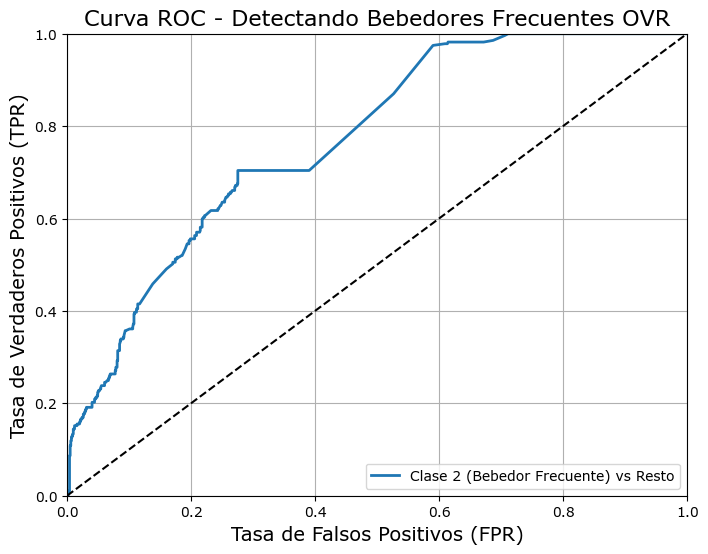

In [9]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.preprocessing import label_binarize

# 1. Calculamos el AUC multiclase global (Uno contra el Resto)
auc = roc_auc_score(y_test, y_pred_proba, multi_class='ovr')
print(f"Área bajo la curva (AUC ROC) Global Multiclase: {auc:.4f}")

# 2. Binarizamos nuestras etiquetas para poder graficar "Clase 2 vs Resto"
y_test_binarized = label_binarize(y_test, classes=[0, 1, 2])

# Calculamos los falsos y verdaderos positivos para la columna de la Clase 2
fpr, tpr, thresholds = roc_curve(y_test_binarized[:, 2], y_pred_proba[:, 2])

# Graficamos la Curva ROC para estimar la habilidad del modelo detectando la Clase 2 en específico
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, linewidth=2, label='Clase 2 (Bebedor Frecuente) vs Resto')
plt.plot([0, 1], [0, 1], 'k--')
plt.axis([0, 1, 0, 1])
plt.xlabel('Tasa de Falsos Positivos (FPR)', fontsize=14)
plt.ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=14)
plt.title('Curva ROC - Detectando Bebedores Frecuentes OVR', fontsize=16)
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

## Resultados Esperados y Conclusión
Si los parámetros provistos en el NHANES resultan ser un buen predictor del hábito general, una *Accuracy* alta junto con altos *F1-Scores* nos indicaría éxito. Sin embargo, al modelar variables demográficas de encuestas de salud como el uso de alcohol, a menudo existe ruido y dependencias no lineales. 
* Esperamos una matriz de confusión modesta pero con la diagonal prevalente a medida que aprende el modelo.
* Si nuestras clases están enormemente desbalanceadas hacia una clase en específico (ej. "no bebedores"), veremos un *Accuracy Global* engañosamente alto pero el puntaje F1 Macro y el Recall de ciertas clases minoritarias decaerán significativamente (esto se evidencia con la matriz de confusión y el reporte Macro).
* El AUC en *One-vs-Rest* nos dirá qué tan bien el modelo puede decir "esta persona pertenece a este tipo de hábito u a otro". Un AUC cercano a 0.5 representa un modelo aleatorio o nulo. Cualquier AUC mayor a 0.70 indica un modelo razonablemente bueno para comportamientos sociales complejos en encuestas.